<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/03_select_hyperparam_for_extraction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [1]:
do = False # @param{type:"boolean"}
if do :
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq
    %pip install starfile -qq
    %pip install https://github.com/soft-matter/trackpy/archive/master.zip -qq

> #### ⚠ Notice
>
> You need to restart the kernel after the following step.

In [2]:
if do :
    %pip install pycuda==2024.1
    %pip install "numpy<2.0"
    %pip install mrcfile -qq

## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [3]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
DATASET_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rm: cannot remove '/content/sample_data': No such file or directory


In [6]:
IMAGE_DIR = "/content/image_dir"

In [7]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

!wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
!wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
!wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
!wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

fatal: destination path 'CryoParticleSegment' already exists and is not an empty directory.
--2026-01-13 00:49:33--  https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17753 (17K) [text/plain]
Saving to: ‘/content/CryoParticleSegment/Modeling/convcrf.py’

/content/CryoPartic 100%[===================>]  17.34K  --.-KB/s    in 0s      

2026-01-13 00:49:33 (168 MB/s) - ‘/content/CryoParticleSegment/Modeling/convcrf.py’ saved [17753/17753]

--2026-01-13 00:49:33--  https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.1

In [8]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

### ✅ Packages Handling

In [9]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

In [10]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery, collate_fn

## ⭐ Main

### ✅ Setting

In [11]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [12]:
# @markdown Parameters.

BATCH = 8
CROP_SIZE = (512, 512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [14]:
crop = transforms.CenterCrop(3840)

In [15]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [16]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [17]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [18]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    shape = i5.shape
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Evaluate

In [19]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
import starfile
import pandas as pd
import matplotlib
from PIL import Image
import cv2

def get_basename_with_uid_removed(path):
  return os.path.basename(path).split(sep='_', maxsplit=1)[-1]


def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy


In [20]:
# @title  { vertical-output: true, display-mode: "form" }
EMPIAR_ID = 10017 # @param {type:"integer"}
RADIUS = 64 # @param {type:"integer"}
# For 10017
BORDER = 128 # @param {type:"integer"}
SIZE = 4096 # @param {type:"integer"}

In [21]:
!cp {DATASET_DIR}/{EMPIAR_ID}/filtered_val.star .

In [22]:
y_size = SIZE
labeled_particles = starfile.read(f"filtered_val.star")['particles']
labeled_particles = labeled_particles[['rlnMicrographName', 'rlnCoordinateX', 'rlnCoordinateY']]
labeled_particles.columns = pd.Index(['image_name', 'x_coord', 'y_coord'])
labeled_particles['image_name'] = labeled_particles['image_name'].apply(get_basename_with_uid_removed)
labeled_particles['image_name'] = labeled_particles['image_name'].apply(lambda s: s.split(".")[0])
labeled_particles['y_coord'] = y_size - labeled_particles['y_coord']
labeled_particles

,image_name,x_coord,y_coord
0,Falcon_2012_06_13-03_22_02_0,2169,1426
1,Falcon_2012_06_13-03_22_02_0,2791,1957
2,Falcon_2012_06_13-03_22_02_0,2372,475
3,Falcon_2012_06_13-03_22_02_0,2635,1047
4,Falcon_2012_06_13-03_22_02_0,3560,3965
...,...,...,...
3540,Falcon_2012_06_12-15_14_01_0,1810,1593
3541,Falcon_2012_06_12-15_14_01_0,1178,1780
3542,Falcon_2012_06_12-15_14_01_0,364,1047
3543,Falcon_2012_06_12-15_14_01_0,961,556


In [23]:
# @title preprocess_and_crop and micrograph functions define
crop_size = 3840 #@param{type:"integer"}

def preprocess_and_crop(micrograph, crop_size=crop_size):
    processed_micrograph = simple_micrograph_preprocessing(micrograph)
    if crop_size:
        mic_width, mic_height = processed_micrograph.shape[1], processed_micrograph.shape[0]
        start_x, start_y = (mic_width - crop_size) // 2, (mic_height - crop_size) // 2
        end_x, end_y = start_x + crop_size, start_y + crop_size
        return processed_micrograph[start_y:end_y, start_x:end_x]
    else:
        return processed_micrograph

def plot_micrograph_and_labels(ax, micrograph, labels, coords):
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(labels, cmap='gray', alpha=0.5)
    for x, y in coords:
        corrected_x, corrected_y = x, y
        circle = matplotlib.patches.Circle((corrected_x, corrected_y), radius=RADIUS, fill=False, color='r')
        ax.add_patch(circle)

You can specify a `crop_size` in `preprocess_and_crop()` to remove boundary artifacts during preprocessing.

In [24]:
label_images = np.empty((0, shape[1], shape[2]), dtype=np.uint8)
gts = []

for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    # if idx == 6:
    #     break
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)
    print(cropped_label_image.shape)
    label_images = np.concatenate((label_images, [cropped_label_image]), axis=0)

    locations = labeled_particles[labeled_particles['image_name'] == name]
    _, ax = plt.subplots(figsize=(12, 12))
    coords = locations[['x_coord', 'y_coord']].values - BORDER
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()
    print(len(coords))
    gts.append(coords)
    ##

#filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
#pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
#save_image(pred_image, pred_path)

Output hidden; open in https://colab.research.google.com to view.

In [25]:
label_images.shape

(6, 3840, 3840)

### Score

> #### 🗒 Info
> Here, we compute the score based on the validation set. You may choose to rank the algorithms using either the F-score or mAP. Additionally, the parameter $\beta$ in the F-score can be adjusted: values of $\beta > 1$ place greater emphasis on recall over precision, while $\beta < 1$ give more weight to precision.


In [26]:
from metrics import centers_to_boxes, calculate_iou_torchvision, evaluate_detection_raw_multiple, f_beta_score, calculate_mAP_multiple_images

In [27]:
# Assign a default confidence score of 1.0 to all predicted boxes
default_score = 1.0
beta = 1 # @param {type:"number"}
F_score = False # @param {type:"boolean"}

---
## DT with circularity, Sphericity, Slenderness at scalar for the mean of front 50% 0.65

In [28]:
# @title particle finding function of watershed
import cv2
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

""" EXAMPLE OF ndimage.distance_transform_edt()
a = np.array(([0,1,1,1,1],
              [0,0,1,1,1],
              [0,1,1,1,1],
              [0,1,1,1,0],
              [0,1,1,0,0]))
ndimage.distance_transform_edt(a)
array([[ 0.    ,  1.    ,  1.4142,  2.2361,  3.    ],
       [ 0.    ,  0.    ,  1.    ,  2.    ,  2.    ],
       [ 0.    ,  1.    ,  1.4142,  1.4142,  1.    ],
       [ 0.    ,  1.    ,  1.4142,  1.    ,  0.    ],
       [ 0.    ,  1.    ,  1.    ,  0.    ,  0.    ]])
"""

def calculate_shape_metrics(region):
    """Computes Sphericity, Circularity, and Inverse Slenderness."""
    area = region.area
    perimeter = region.perimeter
    if perimeter == 0: return 0, 0, 0

    circularity = (4 * np.pi * area) / (perimeter ** 2)

    d_eq = np.sqrt(4 * area / np.pi) # 2r
    d_cir = region.major_axis_length # major
    sphericity = d_eq / d_cir if d_cir > 0 else 0

    # major = region.major_axis_length
    # minor = region.minor_axis_length
    # inv_slenderness = minor / major if major > 0 else 0

    return sphericity, circularity

In [29]:
def get_shape_metrics(region):
    def circularity(region):
        area = region.area
        perimeter = region.perimeter
        return (4 * np.pi * area) / (perimeter ** 2)

    def aspect_ratio(region):
        major_ax = region.major_axis_length
        minor_ax = region.minor_axis_length
        return minor_ax / major_ax # minor to major aspect ratio (present how much the ellispe strech)


---

## Default (adjusted_Z_score_thresholding_range)

### Default (adjusted_Z_score_thresholding_range)

In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0

    regions = regionprops(labels)
    """
    candidates = []
    m_sp, m_cr = [], []

    for region in regions:
        if min_area <= region.area <= max_area:
            sp, cr, isd = calculate_shape_metrics(region)
            candidates.append({'region': region, 'metrics': (sp, cr)})
            m_sp.append(sp); m_cr.append(cr)

    if not candidates: return []

    # 6. Statistical Thresholding (Modified Z-Score / MAD)
    #  MAD statistics thresholding
    def get_mad_range(data, z_thresh=3.0):
        if not data: return 0.0, 1.0
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)

        # Calculate bounds based on 3 median absolute deviations
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    thresh_sp = get_mad_range(m_sp)
    thresh_cr = get_mad_range(m_cr)

    # 7. Auto-Visualization
    # changed) added automatic plotting of the current image's metic distributions
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        metrics = [m_sp, m_cr]
        titles = ['Sphericity', 'Circularity']
        bounds = [thresh_sp, thresh_cr]

        for i in range(2):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.show()
    """
    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40
    """
    for cand in candidates:
        sp, cr, isd = cand['metrics']
        if (thresh_sp[0] <= sp <= thresh_sp[1] and
            thresh_cr[0] <= cr <= thresh_cr[1]):

            region = cand['region']
    """
    for region in regions:
        if True:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
radius = RADIUS

watershed_config = [0.4, 0.8]
watershed_list = []

for img in label_images:
    particles = detect_particles_dt(
        img,
        particle_radius=radius,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1]
    )
    watershed_list.append(particles)

In [ ]:
for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)

    _, ax = plt.subplots(figsize=(12, 12))
    preds = watershed_list[idx]
    coords = [p[:2] for p in preds]
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
### Analysis on Filterd Particles

In [ ]:
def detect_particles_dt_filtered(prob_map_input, particle_radius=64,
                                 peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                                 show_plots=False):
    # --- 1-4. Preprocessing & Watershed (Same as before) ---
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0
    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return {"valid": [], "area_filtered": [], "shape_filtered": []}

    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                      labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)

    # --- 5. Initial Area Filtering ---
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0
    regions = regionprops(labels)

    candidates = []
    area_filtered = []
    m_sp, m_cr = [], []

    for region in regions:
        cy, cx = region.centroid
        if not (min_area <= region.area <= max_area):
            # changed) Collect particles rejected by size
            area_filtered.append([int(cx), int(cy)])
            continue
        sp, cr = calculate_shape_metrics(region)
        candidates.append({'region': region, 'metrics': (sp, cr)})
        m_sp.append(sp); m_cr.append(cr)

    if not candidates:
        return {"valid": [], "area_filtered": area_filtered, "shape_filtered": []}

    # --- 6. Robust Adaptive Thresholding (MAD) ---
    def get_mad_range(data, z_thresh=3.0):
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    t_sp = get_mad_range(m_sp)
    t_cr = get_mad_range(m_cr)

    # --- 8. Final Categorization ---
    valid = []
    shape_filtered = []
    boundary_margin = 40

    for cand in candidates:
        sp, cr = cand['metrics']
        region = cand['region']
        cy, cx = region.centroid

        # Check Adaptive Thresholds
        if (t_sp[0] <= sp <= t_sp[1] and
            t_cr[0] <= cr <= t_cr[1] ):

            # Check Boundary
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                valid.append([int(cx), int(cy), float(prob_map[int(cy), int(cx)])])
            else:
                area_filtered.append([int(cx), int(cy)]) # Boundary rejections treated as area/loc rejection
        else:
            # changed) Collect particles rejected by shape
            shape_filtered.append([int(cx), int(cy)])

    return {
        "valid": valid,
        "area_filtered": area_filtered,
        "shape_filtered": shape_filtered
    }

In [ ]:
def plot_micrograph_filtered(ax, micrograph, labels, particle_dict):
    """
    Plots the results using centered crosses:
    - Red '+': Valid Detections
    - Royalblue 'x': Area Rejections
    - Navy 'x': Shape Rejections
    """
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(labels, cmap='gray', alpha=0.3)

    # 1. Plot Area Filtered (Royalblue Cross)
    if particle_dict['area_filtered']:
        area_pts = np.array(particle_dict['area_filtered'])
        ax.scatter(area_pts[:, 0], area_pts[:, 1], marker='x', color='limegreen',
                   s=100, linewidths=2, label='Area Rejected')

    # 2. Plot Shape Filtered (Navy Cross)
    if particle_dict['shape_filtered']:
        shape_pts = np.array(particle_dict['shape_filtered'])
        ax.scatter(shape_pts[:, 0], shape_pts[:, 1], marker='x', color='navy',
                   s=100, linewidths=2, label='Shape Rejected')

    # 3. Plot Valid (Red Plus)
    if particle_dict['valid']:
        valid_pts = np.array(particle_dict['valid'])
        ax.scatter(valid_pts[:, 0], valid_pts[:, 1], marker='+', color='red',
                   s=150, linewidths=1.5, label='Valid')

    # Handle Legend (prevent duplicate labels)
    handles, labels_lg = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_lg, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True)

In [ ]:
# Run detection
watershed_config = [0.4, 0.8]

watershed_results_full = []
for img in label_images:
    res = detect_particles_dt_filtered(
        img,
        particle_radius=RADIUS,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1],
        show_plots=False # Set to True to see the histograms
    )
    watershed_results_full.append(res)

In [ ]:
for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(np.array(Image.open(label_path)))

    fig, ax = plt.subplots(figsize=(12, 12))

    # Use the dictionary containing all categories
    particle_dict = watershed_results_full[idx]

    plot_micrograph_filtered(ax, cropped_micrograph, cropped_label_image, particle_dict)

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---

In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8
 -> Finished generating 1 candidates.


In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_defalut" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_default_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.9599, mAP: 0.8355

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_defalut', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.9599174768759454, 'map': 0.8354761004447937}
✅ Saved locally to: best_watershed_default_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF/best_watershed_default_params.json


---

## Area

In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0

    regions = regionprops(labels)

    candidates = []
    m_sp, m_cr = [], []

    for region in regions:
        if min_area <= region.area <= max_area:
            sp, cr = calculate_shape_metrics(region)
            candidates.append({'region': region, 'metrics': (sp, cr)})
            m_sp.append(sp); m_cr.append(cr)

    if not candidates: return []

    # 6. Statistical Thresholding (Modified Z-Score / MAD)
    #  MAD statistics thresholding
    def get_mad_range(data, z_thresh=3.0):
        if not data: return 0.0, 1.0
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)

        # Calculate bounds based on 3 median absolute deviations
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    thresh_sp = get_mad_range(m_sp)
    thresh_cr = get_mad_range(m_cr)

    # 7. Auto-Visualization
    # changed) added automatic plotting of the current image's metic distributions
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        metrics = [m_sp, m_cr]
        titles = ['Sphericity', 'Circularity']
        bounds = [thresh_sp, thresh_cr]

        for i in range(2):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.close()

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40

    for cand in candidates:
        sp, cr = cand['metrics']
        # if (thresh_sp[0] <= sp <= thresh_sp[1] and
        #    thresh_cr[0] <= cr <= thresh_cr[1]):

        if True:
            region = cand['region']
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8
 -> Finished generating 1 candidates.


In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_area" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_area_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.9598, mAP: 0.8353

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_area', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.9597641854208506, 'map': 0.8353387713432312}
✅ Saved locally to: best_watershed_area_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF/best_watershed_area_params.json


---

## shape metrics only

In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0

    regions = regionprops(labels)

    candidates = []
    m_sp, m_cr = [], []

    for region in regions:
        #if min_area <= region.area <= max_area:
        if True:
            sp, cr = calculate_shape_metrics(region)
            candidates.append({'region': region, 'metrics': (sp, cr)})
            m_sp.append(sp); m_cr.append(cr)

    if not candidates: return []

    # 6. Statistical Thresholding (Modified Z-Score / MAD)
    #  MAD statistics thresholding
    def get_mad_range(data, z_thresh=3.0):
        if not data: return 0.0, 1.0
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)

        # Calculate bounds based on 3 median absolute deviations
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    thresh_sp = get_mad_range(m_sp)
    thresh_cr = get_mad_range(m_cr)

    # 7. Auto-Visualization
    # changed) added automatic plotting of the current image's metic distributions
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        metrics = [m_sp, m_cr]
        titles = ['Sphericity', 'Circularity']
        bounds = [thresh_sp, thresh_cr]

        for i in range(2):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.show()

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40

    for cand in candidates:
        sp, cr = cand['metrics']
        if (thresh_sp[0] <= sp <= thresh_sp[1] and
            thresh_cr[0] <= cr <= thresh_cr[1]):

            region = cand['region']
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8


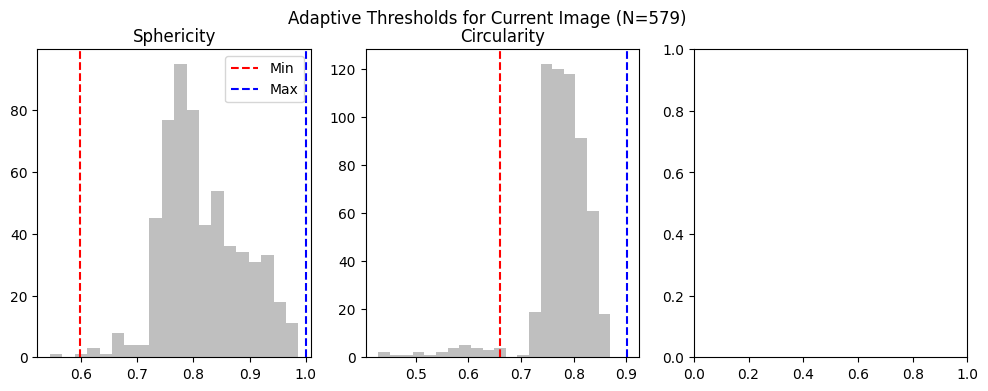

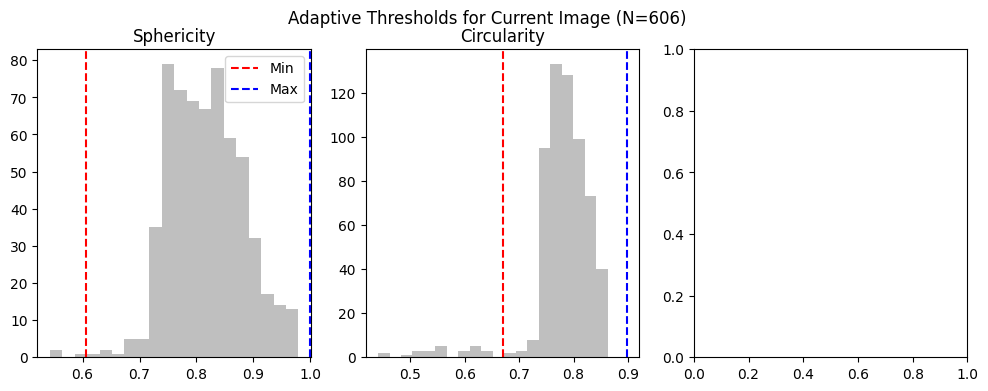

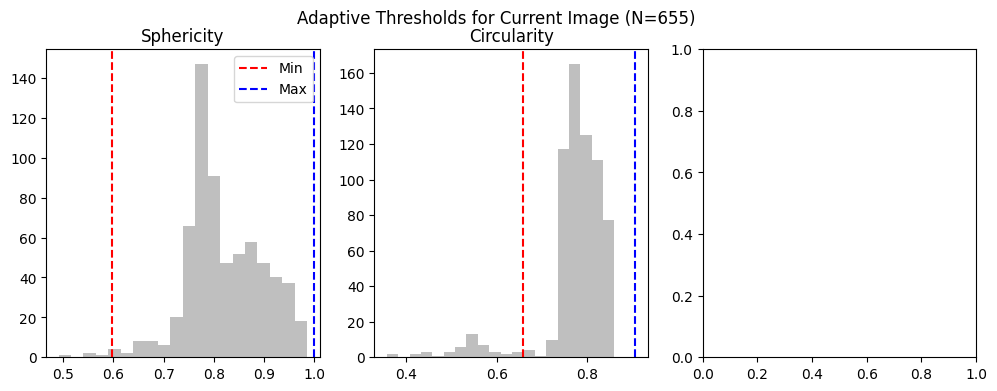

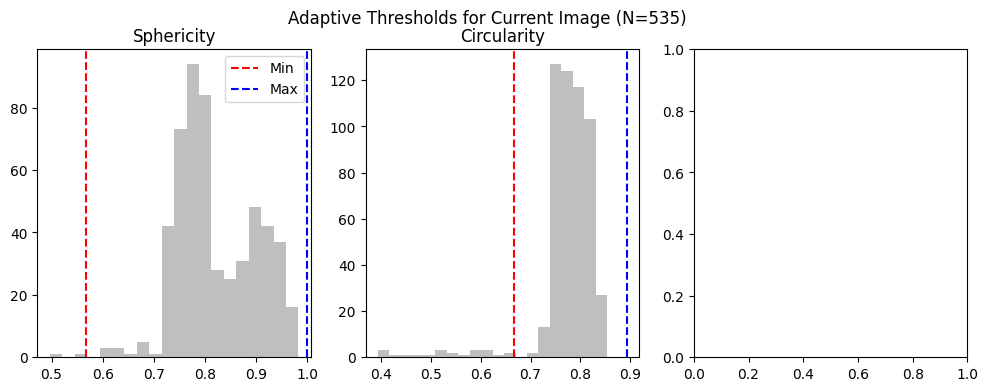

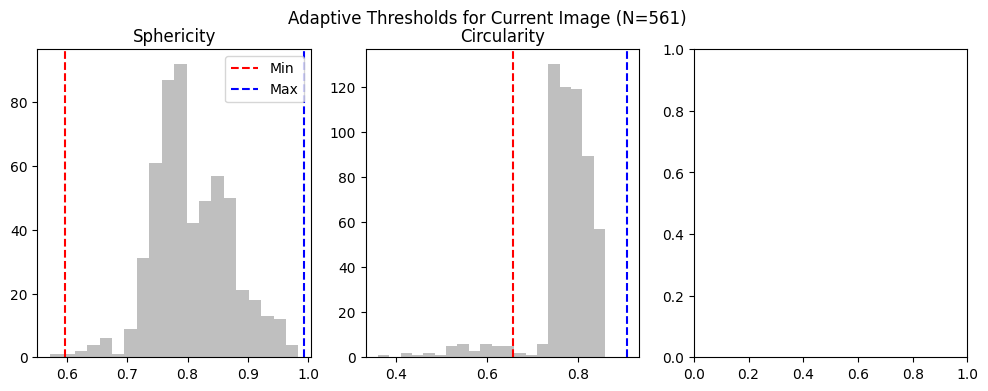

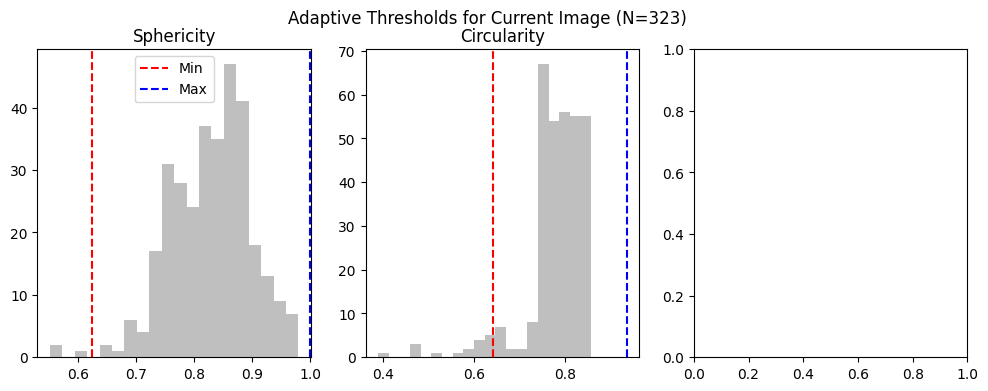

 -> Finished generating 1 candidates.


In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_shape_metrics" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_shape_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.9331, mAP: 0.8461

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_shape_metrics', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.9330714606638251, 'map': 0.8461431860923767}
✅ Saved locally to: best_watershed_shape_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF/best_watershed_shape_params.json


---

## all thres

In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0

    regions = regionprops(labels)

    candidates = []
    m_sp, m_cr = [], []

    for region in regions:
        if min_area <= region.area <= max_area:
            sp, cr = calculate_shape_metrics(region)
            candidates.append({'region': region, 'metrics': (sp, cr)})
            m_sp.append(sp); m_cr.append(cr)

    if not candidates: return []

    # 6. Statistical Thresholding (Modified Z-Score / MAD)
    #  MAD statistics thresholding
    def get_mad_range(data, z_thresh=3.0):
        if not data: return 0.0, 1.0
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)

        # Calculate bounds based on 3 median absolute deviations
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    thresh_sp = get_mad_range(m_sp)
    thresh_cr = get_mad_range(m_cr)

    # 7. Auto-Visualization
    # changed) added automatic plotting of the current image's metic distributions
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        metrics = [m_sp, m_cr]
        titles = ['Sphericity', 'Circularity']
        bounds = [thresh_sp, thresh_cr]

        for i in range(2):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.show()

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40

    for cand in candidates:
        sp, cr = cand['metrics']
        if (thresh_sp[0] <= sp <= thresh_sp[1] and
            thresh_cr[0] <= cr <= thresh_cr[1]):

            region = cand['region']
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8


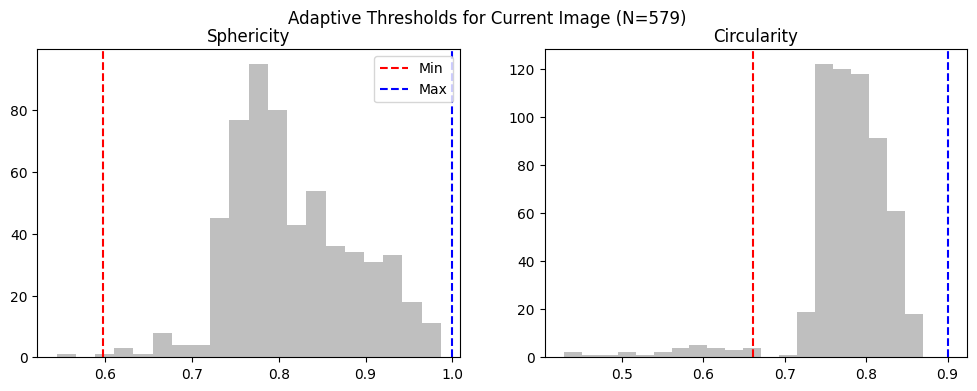

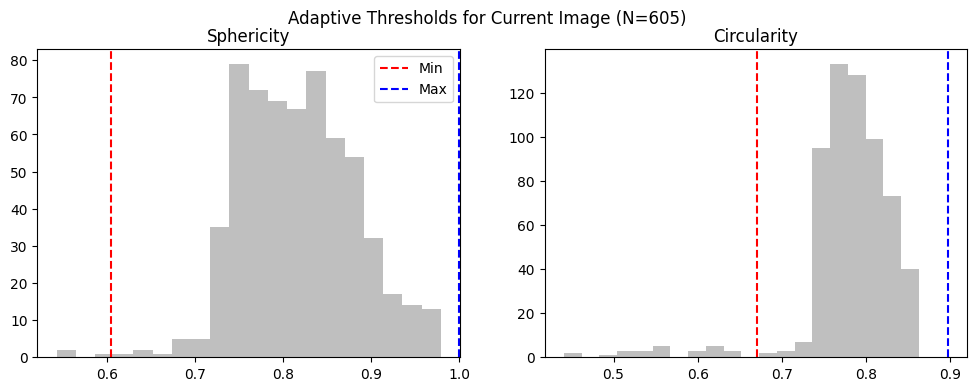

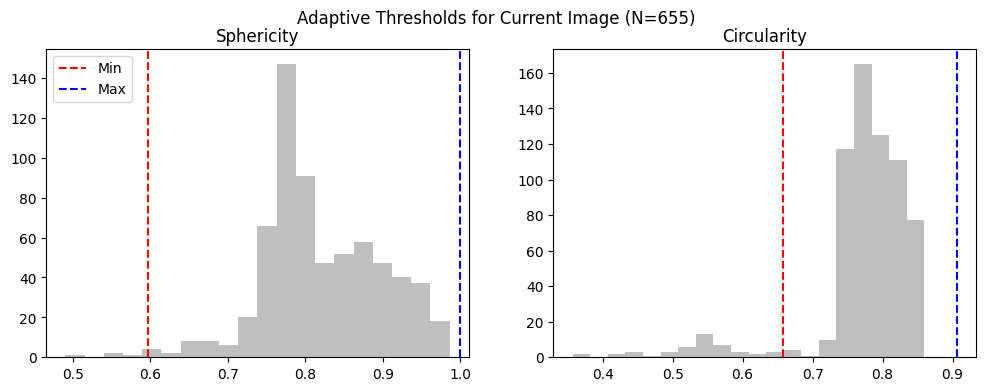

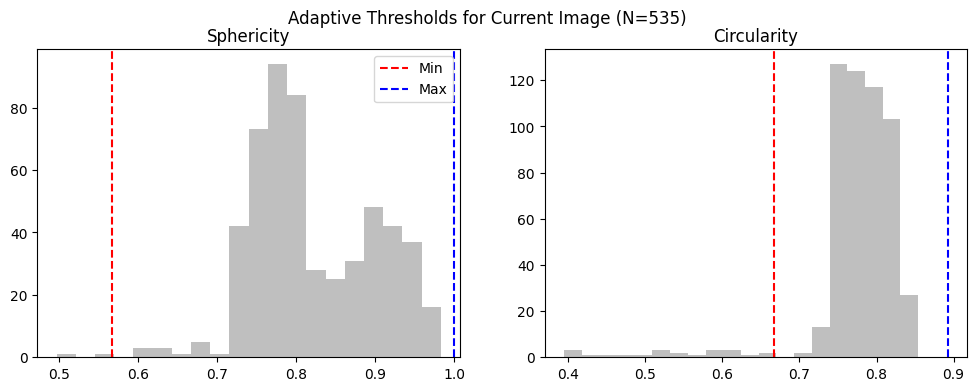

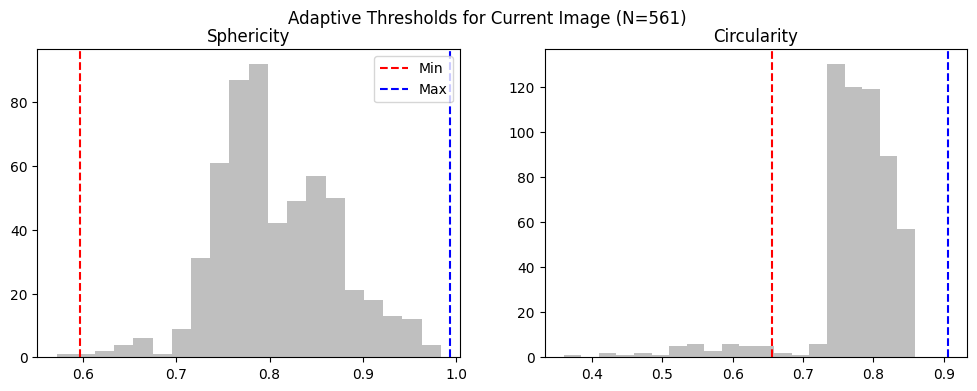

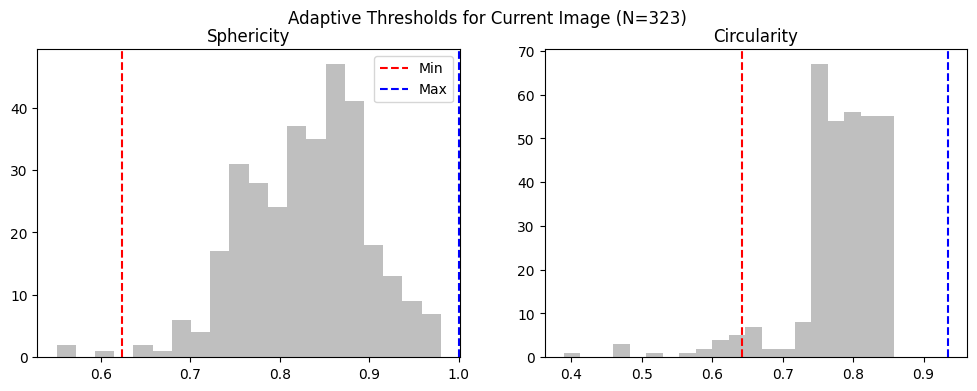

 -> Finished generating 1 candidates.


In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_all" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_all_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.9329, mAP: 0.8460

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_all', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.9329102445050137, 'map': 0.8460099101066589}
✅ Saved locally to: best_watershed_all_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF/best_watershed_all_params.json


## Ending

## No Any Constrain

In [30]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding

    local_max_coords = peak_local_max(
        distance,
        labels=binary_mask,
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)

    regions = regionprops(labels)

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40

    for region in regions:
        if True:
            cy, cx = region.centroid
            # if (boundary_margin < cx < width - boundary_margin and
            #    boundary_margin < cy < height - boundary_margin):
            if True:
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [31]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8
 -> Finished generating 1 candidates.


In [32]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [33]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_NoCON" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_noCON_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.2788, mAP: 2.2073

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_NoCON', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.27883745622536377, 'map': 2.2072958946228027}
✅ Saved locally to: best_watershed_noCON_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_indiv_test/10017/unet_eb5_dice_CRF/best_watershed_noCON_params.json


---